<a href="https://colab.research.google.com/github/alfredo170987/Proyecto-1-Sistemas-de-Comunicaci-n/blob/main/Notebook_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Notebook 2: Deep JSCC para Transmisión de Imágenes sobre Canales Inalámbricos

Aquí subes el nivel aplicando Codificación Conjunta de Fuente y Canal (JSCC) real. En lugar de transmitir bits, el Autoencoder aprende a transmitir características semánticas de una imagen directamente como símbolos analógicos a través del canal.

• Entrada: Dataset de imágenes pequeñas (como CIFAR-10 o MNIST).

• Encoder: Capas Convolucionales (nn.Conv2d) que reducen la dimensionalidad de la imagen (compresión de fuente) y la preparan para el canal (compresión de canal).

• Canal: Simulación de un canal inalámbrico variable (puedes empezar con AWGN y, si quieres un extra, simular un canal con desvanecimiento tipo Rayleigh).
• Decoder: Capas Convolucionales Transpuestas o Upsampling (nn.ConvTranspose2d) que reconstruyen la imagen a partir de los símbolos ruidosos recibidos.

• Función de Pérdida: Error Cuadrático Medio (MSE) entre la imagen original y la reconstruida.

• Métricas a graficar:

	• Visualización de imágenes originales vs. reconstruidas a diferentes niveles de ruido (baja SNR vs. alta SNR).
	• Curva de PSNR (Peak Signal-to-Noise Ratio) o SSIM vs. SNR del canal para demostrar el efecto de "degradación suave" (a diferencia de los sistemas tradicionales, JSCC no sufre el efecto acantilado donde la comunicación se corta de golpe al bajar la señal).

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# 1. CONFIGURACIÓN E HIPERPARÁMETROS
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128
EPOCHS = 10

# Carga de datos (MNIST: imágenes de 1x28x28 = 784 píxeles)
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 2. DEFINICIÓN DEL MODELO DEEP JSCC
class DeepJSCC(nn.Module):
    def __init__(self):
        super(DeepJSCC, self).__init__()

        # ENCODER: Compresión de fuente y canal combinadas
        # Reduce la imagen de 1x28x28 a una representación pequeña de canales
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, stride=2, padding=2), # -> 16 x 14 x 14
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=5, stride=2, padding=2), # -> 32 x 7 x 7
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 32) # Transmitiremos 32 símbolos por el canal (Espacio I/Q)
        )

        # DECODER: Recuperación de la señal ruidosa y reconstrucción de píxeles
        self.decoder = nn.Sequential(
            nn.Linear(32, 32 * 7 * 7),
            nn.ReLU(),
            nn.Unflatten(1, (32, 7, 7)),
            nn.ConvTranspose2d(32, 16, kernel_size=5, stride=2, padding=2, output_padding=1), # -> 16 x 14 x 14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=5, stride=2, padding=2, output_padding=1),  # -> 1 x 28 x 28
            nn.Sigmoid() # Mapea los píxeles al rango [0, 1]
        )

    def forward(self, x, snr_dB):
        # 1. Codificación
        x_symbols = self.encoder(x)

        # 2. Restricción de potencia (Tus fórmulas)
        potencia = torch.mean(x_symbols ** 2)
        x_tx = x_symbols / torch.sqrt(potencia)

        # 3. Canal AWGN (Tus fórmulas)
        snr_linear = 10 ** (snr_dB / 10.0)
        noise_var = 1.0 / (snr_linear)

        ruido = torch.randn_like(x_tx) * torch.sqrt(torch.tensor(noise_var, device=device))
        x_rx = x_tx + ruido

        # 4. Decodificación
        x_recon = self.decoder(x_rx)
        return x_recon

# 3. INSTANCIAR Y ENTRENAR
model = DeepJSCC().to(device)
criterion = nn.MSELoss() # Evaluamos qué tan parecidos son los píxeles [1]
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Entrenamos con una SNR variable para que la red aprenda a defenderse en varios escenarios
print(f"Entrenando Deep JSCC en {device}...")
for epoch in range(EPOCHS):
    model.train()
    loss_total = 0
    for images, _ in train_loader:
        images = images.to(device)

        # SNR aleatoria por lote entre 0 y 15 dB para robustez
        snr_batch = np.random.uniform(0, 15)

        optimizer.zero_grad()
        outputs = model(images, snr_batch)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()

        loss_total += loss.item()

    print(f"Época [{epoch+1}/{EPOCHS}], Pérdida (MSE): {loss_total/len(train_loader):.4f}")

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.47MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 153kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.92MB/s]


Entrenando Deep JSCC en cpu...
Época [1/10], Pérdida (MSE): 0.0476
Época [2/10], Pérdida (MSE): 0.0214
Época [3/10], Pérdida (MSE): 0.0180
Época [4/10], Pérdida (MSE): 0.0176
Época [5/10], Pérdida (MSE): 0.0164
Época [6/10], Pérdida (MSE): 0.0160
Época [7/10], Pérdida (MSE): 0.0163
Época [8/10], Pérdida (MSE): 0.0162
Época [9/10], Pérdida (MSE): 0.0155
Época [10/10], Pérdida (MSE): 0.0158


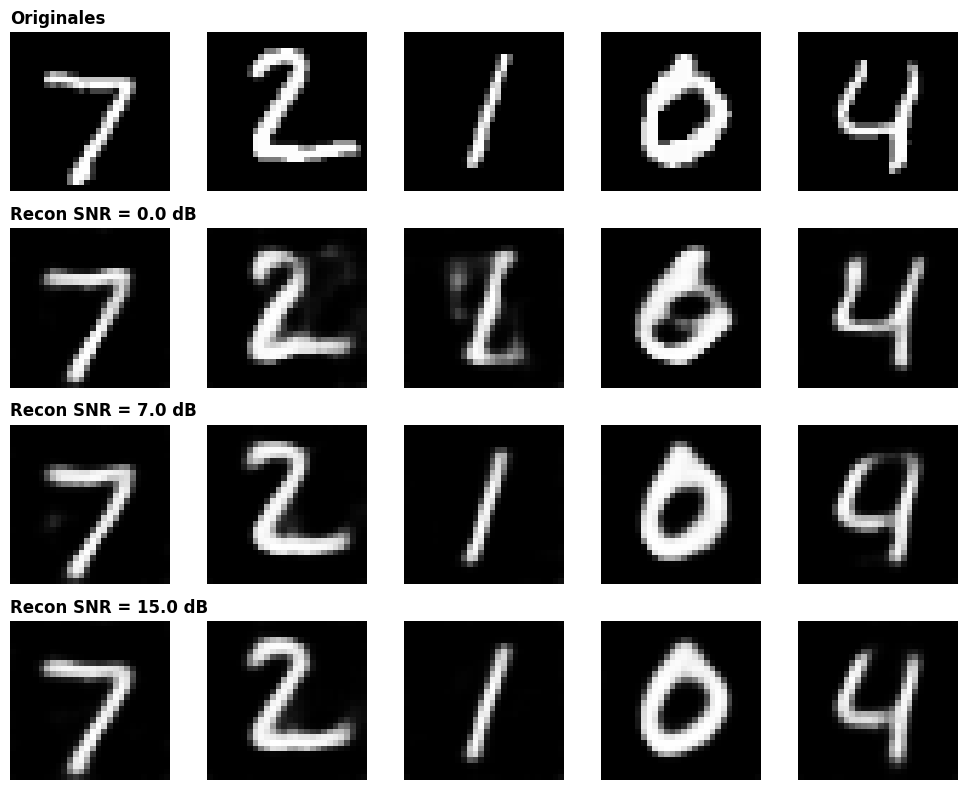

In [2]:
model.eval()
images, _ = next(iter(test_loader))
images = images.to(device)

snrs_to_test = [0.0, 7.0, 15.0]
fig, axes = plt.subplots(4, 5, figsize=(10, 8))

# Fila 0: Imágenes Originales
for i in range(5):
    axes[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
axes[0, 0].set_title("Originales", loc='left', fontsize=12, fontweight='bold')

# Filas 1 a 3: Reconstrucciones a diferentes SNRs
with torch.no_grad():
    for row, snr in enumerate(snrs_to_test, start=1):
        recon_images = model(images, snr)
        for i in range(5):
            axes[row, i].imshow(recon_images[i].cpu().squeeze(), cmap='gray')
            axes[row, i].axis('off')
        axes[row, 0].set_title(f"Recon SNR = {snr} dB", loc='left', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()